# 04 — Modèle 2 pour la recommandation (dataset annexe)

Objectif de ce notebook :

1. repartir du **dataset annexe consolidé** déjà préparé dans le notebook 1 ;
2. faire une **exploration complémentaire ciblée** (outliers, valeurs impossibles, catégories trop peu représentées) ;
3. construire un **modèle 2** orienté **recommandation de cultures** ;
4. comparer un modèle **benchmark maximal** et un modèle **déployable** ;
5. préparer la logique qui alimentera plus tard l’endpoint `/recommend`.

## Rappel important

Ce notebook ne refait **pas** toute l’EDA de base.  
Il se concentre sur les décisions utiles pour le moteur de recommandation.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from project_paths import PROCESSED_DIR

OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

import mlflow
import mlflow.sklearn

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False

SEED = 42

In [2]:
MLFLOW_DB_PATH = ROOT / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH.as_posix()}")
mlflow.set_experiment("agritech-model-2-recommendation")
print("MLflow tracking URI:", mlflow.get_tracking_uri())

2026/03/27 13:42:41 INFO mlflow.tracking.fluent: Experiment with name 'agritech-model-2-recommendation' does not exist. Creating a new experiment.


MLflow tracking URI: sqlite:///C:/Users/thoma/Documents/Openclassroom/Projet-12/mlflow.db


## 1. Chargement du dataset annexe consolidé

D’après le notebook 1, le fichier consolidé provient de la fusion des sources :
- rendement ;
- pesticides ;
- pluie ;
- température.

Colonnes attendues :
- `Area`
- `Item`
- `Year`
- `Unit`
- `hg/ha_yield`
- `pesticides_tonnes`
- `average_rain_fall_mm_per_year`
- `avg_temp`

In [3]:
df = pd.read_csv(PROCESSED_DIR / "yield_dataset_consolidated.csv")
print(df.shape)
display(df.head())
df.dtypes

(13136, 8)


,Area,Item,Year,Unit,hg/ha_yield,pesticides_tonnes,average_rain_fall_mm_per_year,avg_temp
0,Albania,Maize,1990,hg/ha,36613,121.0,1485.0,16.37
1,Albania,Maize,1991,hg/ha,29068,121.0,1485.0,15.36
2,Albania,Maize,1992,hg/ha,24876,121.0,1485.0,16.06
3,Albania,Maize,1993,hg/ha,24185,121.0,1485.0,16.05
4,Albania,Maize,1994,hg/ha,25848,201.0,1485.0,16.96


Area                              object
Item                              object
Year                               int64
Unit                              object
hg/ha_yield                        int64
pesticides_tonnes                float64
average_rain_fall_mm_per_year    float64
avg_temp                         float64
dtype: object

## 2. Vérifications ciblées rapides

Ici, on ne refait pas l’EDA complète.  
On vérifie seulement les points qui peuvent impacter la modélisation :
- doublons ;
- valeurs manquantes ;
- types ;
- plages aberrantes.

In [4]:
# Typage défensif
num_cols = [
    "Year",
    "hg/ha_yield",
    "pesticides_tonnes",
    "average_rain_fall_mm_per_year",
    "avg_temp",
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Shape :", df.shape)
print("Doublons exacts :", df.duplicated().sum())
print("Doublons Area/Item/Year :", df.duplicated(subset=["Area", "Item", "Year"]).sum())
print("\nValeurs manquantes :")
display(df.isna().sum().sort_values(ascending=False))

Shape : (13136, 8)
Doublons exacts : 0
Doublons Area/Item/Year : 0

Valeurs manquantes :


average_rain_fall_mm_per_year    6
Area                             0
Year                             0
Item                             0
Unit                             0
hg/ha_yield                      0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [5]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Year,13136.0,2001.617692,7.035556,1990.00,1995.0000,2001.00,2008.00,2013.00
hg/ha_yield,13136.0,70959.634440,79111.427638,50.00,18000.0000,39536.00,97159.00,501412.00
pesticides_tonnes,13136.0,14832.141503,33646.165696,0.04,264.5825,2170.40,13335.22,367778.00
average_rain_fall_mm_per_year,13130.0,1157.238766,743.622488,51.00,608.0000,1083.00,1651.00,3240.00
avg_temp,13136.0,19.839209,6.657741,1.30,15.6700,20.62,25.78,30.42


## 3. Contrôles métier et valeurs impossibles

On distingue deux choses :

- **valeurs impossibles** au sens métier ;
- **outliers** au sens statistique.

Exemples :
- `hg/ha_yield < 0` : impossible ;
- `average_rain_fall_mm_per_year < 0` : impossible ;
- `pesticides_tonnes < 0` : impossible ;
- `avg_temp < 0` : **pas forcément** impossible selon les zones.

Commencer par mesurer ces cas avant de décider quoi faire.

In [6]:
impossible_summary = {
    "yield_negatif": int((df["hg/ha_yield"] < 0).sum()),
    "rain_negatif": int((df["average_rain_fall_mm_per_year"] < 0).sum()),
    "pesticides_negatif": int((df["pesticides_tonnes"] < 0).sum()),
}
impossible_summary

{'yield_negatif': 0, 'rain_negatif': 0, 'pesticides_negatif': 0}

In [7]:
# Décision à adapter après inspection :
# - supprimer les valeurs métier impossibles
# - ne PAS supprimer la température négative par principe

df_model = df.copy()

df_model = df_model[df_model["hg/ha_yield"] >= 0].copy()
df_model = df_model[df_model["average_rain_fall_mm_per_year"] >= 0].copy()
df_model = df_model[df_model["pesticides_tonnes"] >= 0].copy()
df_model["yield_t_ha"] = df_model["hg/ha_yield"] / 10000.0

display(
    df_model[["hg/ha_yield", "yield_t_ha"]].describe().T
)
# Typage défensif
num_cols = [
    "Year",
    "hg/ha_yield",
    "pesticides_tonnes",
    "average_rain_fall_mm_per_year",
    "avg_temp",
    "yield_t_ha",
]

print("Shape après nettoyage métier :", df_model.shape)
df_model[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
hg/ha_yield,13130.0,70968.615461,79124.283809,50.000,18000.0,39543.50000,97152.250000,501412.0000
yield_t_ha,13130.0,7.096862,7.912428,0.005,1.8,3.95435,9.715225,50.1412


Shape après nettoyage métier : (13130, 9)


,count,mean,std,min,25%,50%,75%,max
Year,13130.0,2001.622772,7.033139,1990.000,1995.00,2001.00000,2008.000000,2013.0000
hg/ha_yield,13130.0,70968.615461,79124.283809,50.000,18000.00,39543.50000,97152.250000,501412.0000
pesticides_tonnes,13130.0,14838.697886,33652.454670,0.040,264.53,2172.20000,13335.220000,367778.0000
average_rain_fall_mm_per_year,13130.0,1157.238766,743.622488,51.000,608.00,1083.00000,1651.000000,3240.0000
avg_temp,13130.0,19.836531,6.658083,1.300,15.67,20.62000,25.780000,30.4200
yield_t_ha,13130.0,7.096862,7.912428,0.005,1.80,3.95435,9.715225,50.1412


## 4. Exploration complémentaire des outliers

Ici, l’objectif n’est pas forcément de tout supprimer.

Pour la recommandation, il faut surtout savoir :
- si certaines distributions sont extrêmement asymétriques ;
- si une transformation simple (par ex. `log1p`) serait utile ;
- si quelques points extrêmes dominent le signal.

Point d’attention particulier :
- `pesticides_tonnes` risque d’être très asymétrique.

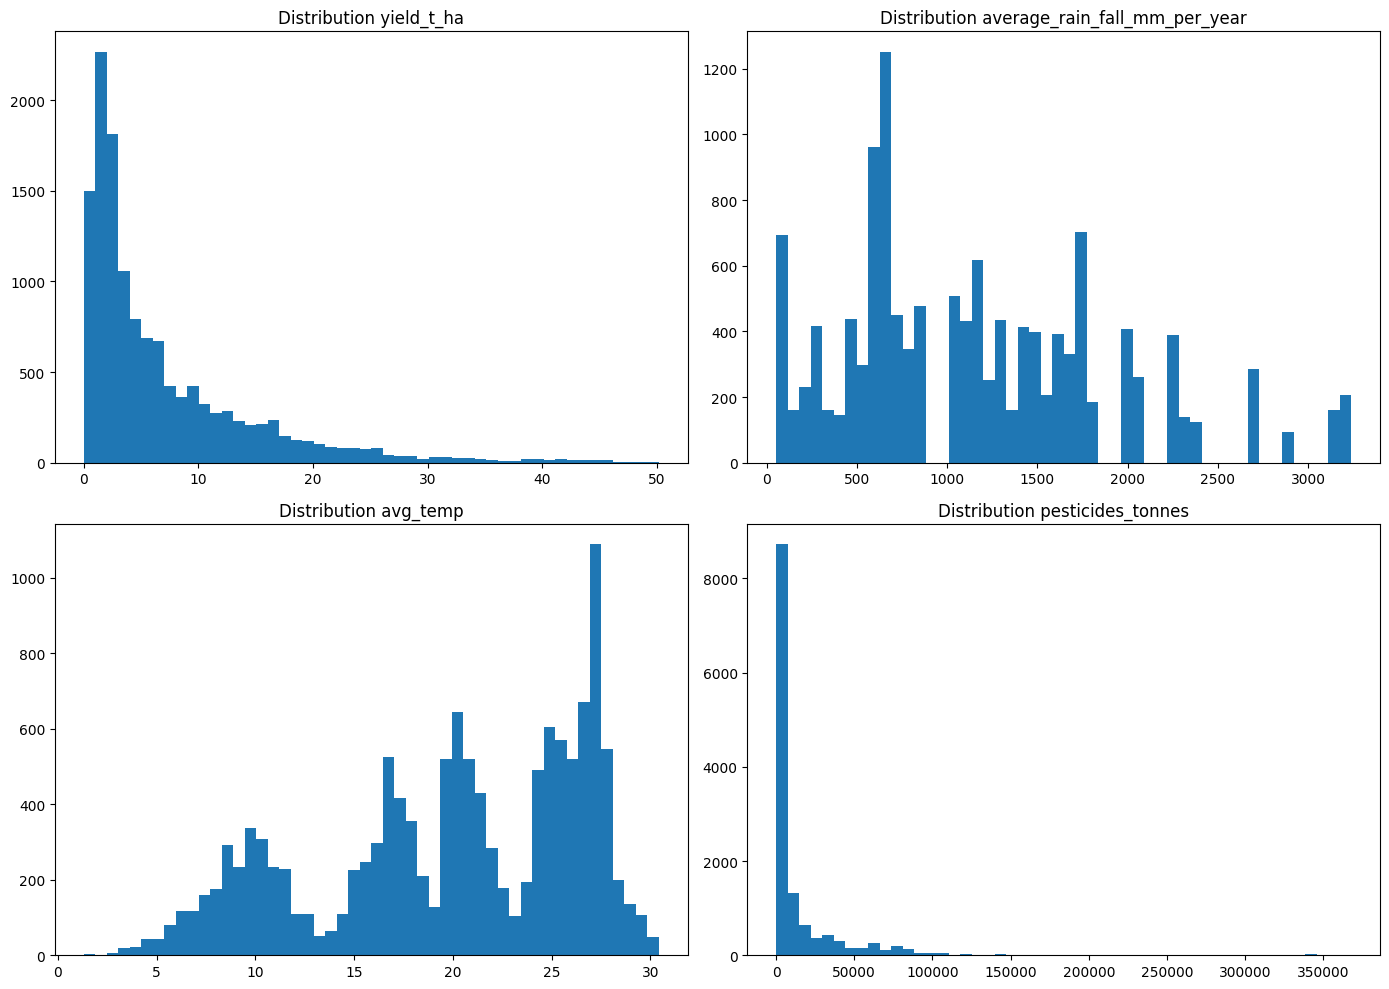

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_model["yield_t_ha"], bins=50)
axes[0, 0].set_title("Distribution yield_t_ha")

axes[0, 1].hist(df_model["average_rain_fall_mm_per_year"], bins=50)
axes[0, 1].set_title("Distribution average_rain_fall_mm_per_year")

axes[1, 0].hist(df_model["avg_temp"], bins=50)
axes[1, 0].set_title("Distribution avg_temp")

axes[1, 1].hist(df_model["pesticides_tonnes"], bins=50)
axes[1, 1].set_title("Distribution pesticides_tonnes")
plt.tight_layout()
plt.show()

In [9]:
# Variante utile à tester si pesticides_tonnes est très skewed
df_model["log1p_pesticides_tonnes"] = np.log1p(df_model["pesticides_tonnes"])
df_model[["pesticides_tonnes", "log1p_pesticides_tonnes"]].describe().T

,count,mean,std,min,25%,50%,75%,max
pesticides_tonnes,13130.0,14838.697886,33652.454670,0.040000,264.530000,2172.200000,13335.220000,367778.000000
log1p_pesticides_tonnes,13130.0,7.474329,2.577593,0.039221,5.581728,7.683956,9.498239,12.815237


In [10]:
# IQR simple pour lecture, sans suppression automatique
def iqr_summary(series: pd.Series) -> dict:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (series < low) | (series > high)
    return {
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "low": low,
        "high": high,
        "n_outliers": int(mask.sum()),
        "pct_outliers": float(mask.mean()),
    }

outlier_report = pd.DataFrame({
    col: iqr_summary(df_model[col].dropna())
    for col in ["yield_t_ha", "average_rain_fall_mm_per_year", "avg_temp", "pesticides_tonnes"]
}).T

outlier_report

,q1,q3,iqr,low,high,n_outliers,pct_outliers
yield_t_ha,1.80,9.715225,7.915225,-10.072838,21.588062,814.0,0.061995
average_rain_fall_mm_per_year,608.00,1651.000000,1043.000000,-956.500000,3215.500000,207.0,0.015765
avg_temp,15.67,25.780000,10.110000,0.505000,40.945000,0.0,0.000000
pesticides_tonnes,264.53,13335.220000,13070.690000,-19341.505000,32941.255000,1936.0,0.147449


## 5. Catégories peu représentées : cultures et zones géographiques

Pour la recommandation, c’est un point central.

Une culture très rare peut :
- dégrader le modèle ;
- produire une recommandation trompeuse ;
- ou devoir être conservée mais avec une **confiance plus faible**.

Même logique pour certaines zones (`Area`).

In [11]:
item_counts = df_model["Item"].value_counts().rename_axis("Item").reset_index(name="n_obs")
area_counts = df_model["Area"].value_counts().rename_axis("Area").reset_index(name="n_obs")

display(item_counts.head(20))
display(area_counts.head(20))

,Item,n_obs
0,Potatoes,2091
1,Maize,2028
2,Wheat,1810
3,"Rice, paddy",1502
4,Sorghum,1435
5,Soybeans,1242
6,Sweet potatoes,1163
7,Cassava,941
8,Plantains and others,464
9,Yams,454


,Area,n_obs
0,Cameroon,230
1,Kenya,230
2,Colombia,207
3,Brazil,207
4,Burundi,207
5,Peru,207
6,Rwanda,207
7,Mali,207
8,Uganda,207
9,Ecuador,207


In [12]:
# A ajuster après lecture des distributions
MIN_ITEM_SUPPORT = 100
MIN_AREA_SUPPORT = 50

supported_items = set(item_counts.loc[item_counts["n_obs"] >= MIN_ITEM_SUPPORT, "Item"])
supported_areas = set(area_counts.loc[area_counts["n_obs"] >= MIN_AREA_SUPPORT, "Area"])

print("Cultures retenues :", len(supported_items))
print("Zones retenues :", len(supported_areas))

df_supported = df_model[
    df_model["Item"].isin(supported_items) &
    df_model["Area"].isin(supported_areas)
].copy()

print("Shape après filtre de support :", df_supported.shape)

Cultures retenues : 10
Zones retenues : 90
Shape après filtre de support : (12710, 10)


## 6. Définition des deux objectifs de modélisation

### A. Modèle benchmark maximal
Objectif : voir la meilleure performance qu’on peut obtenir sur ce dataset.

Features candidates :
- `Area`
- `Item`
- `Year`
- `average_rain_fall_mm_per_year`
- `avg_temp`
- `pesticides_tonnes` ou `log1p_pesticides_tonnes`

### B. Modèle déployable pour `/recommend`
Objectif : garder seulement des variables utilisables au moment de la recommandation.

Idée initiale :
- `Area`
- `Item`
- `average_rain_fall_mm_per_year`
- `avg_temp`

Pourquoi exclure `pesticides_tonnes` ?
Parce que l’utilisateur risque de ne **pas** connaître cette valeur au moment de la recommandation.

Pourquoi exclure `Year` ?
Parce qu’en production, on ne veut pas dépendre d’une année historique arbitraire sauf stratégie claire.

In [13]:
target_col = "yield_t_ha"

benchmark_features = [
    "Area",
    "Item",
    "Year",
    "average_rain_fall_mm_per_year",
    "avg_temp",
    "log1p_pesticides_tonnes",
]

deploy_features = [
    "Area",
    "Item",
    "average_rain_fall_mm_per_year",
    "avg_temp",
]

benchmark_df = df_supported[benchmark_features + [target_col]].dropna().copy()
deploy_df = df_supported[deploy_features + [target_col]].dropna().copy()

print("Benchmark df :", benchmark_df.shape)
print("Deploy df :", deploy_df.shape)

Benchmark df : (12710, 7)
Deploy df : (12710, 5)


## 7. Split train / test

In [14]:
def split_xy(df_in: pd.DataFrame, features: list[str], target: str):
    X = df_in[features].copy()
    y = df_in[target].copy()
    return train_test_split(X, y, test_size=0.2, random_state=SEED)

X_train_b, X_test_b, y_train_b, y_test_b = split_xy(benchmark_df, benchmark_features, target_col)
X_train_d, X_test_d, y_train_d, y_test_d = split_xy(deploy_df, deploy_features, target_col)

print(X_train_b.shape, X_test_b.shape)
print(X_train_d.shape, X_test_d.shape)

(10168, 6) (2542, 6)
(10168, 4) (2542, 4)


## 8. Préprocessing

On utilise une pipeline simple et propre :
- imputation médiane + standardisation pour les numériques ;
- imputation du mode + one-hot encoding pour les catégorielles.

In [15]:
def make_preprocessor(X: pd.DataFrame, force_dense: bool = False) -> ColumnTransformer:
    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer([
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ])

## 9. Benchmark initial des modèles

Le but n’est pas de lancer immédiatement un énorme tuning, mais de répondre à une question claire :

> Le dataset annexe permet-il de construire un modèle utile pour la recommandation ?

In [16]:
def make_preprocessor(X: pd.DataFrame, force_dense: bool = False) -> ColumnTransformer:
    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=not force_dense
            ),
        ),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ],
        sparse_threshold=0 if force_dense else 0.3,
    )

In [17]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluate_models(X_train, X_test, y_train, y_test, use_catboost=False):
    models = {
        "dummy_mean": DummyRegressor(strategy="mean"),
        "ridge": Ridge(alpha=1.0),
        "random_forest": RandomForestRegressor(
            n_estimators=200,
            random_state=SEED,
            n_jobs=-1
        ),
        "hist_gb": HistGradientBoostingRegressor(
            random_state=SEED
        ),
    }

    if use_catboost and CATBOOST_AVAILABLE:
        models["catboost"] = CatBoostRegressor(
            verbose=0,
            random_state=SEED,
            allow_writing_files=False,
        )

    rows = []

    for name, model in models.items():
        force_dense = name == "hist_gb"
        preprocessor = make_preprocessor(X_train, force_dense=force_dense)

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model),
        ])

        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)

        rows.append({
            "model": name,
            "rmse": rmse(y_test, preds),
            "mae": mean_absolute_error(y_test, preds),
            "r2": r2_score(y_test, preds),
        })

    return pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    

In [18]:
def log_benchmark_table_to_mlflow(
    results_df: pd.DataFrame,
    run_name: str,
    feature_set_name: str,
    features: list[str],
    target_col: str,
    target_unit: str = "t/ha",
):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("feature_set_name", feature_set_name)
        mlflow.log_param("target_col", target_col)
        mlflow.log_param("target_unit", target_unit)
        mlflow.log_param("n_features", len(features))
        mlflow.log_param("features", ",".join(features))

        for _, row in results_df.iterrows():
            model_name = row["model"]
            mlflow.log_metric(f"{model_name}_rmse", float(row["rmse"]))
            mlflow.log_metric(f"{model_name}_mae", float(row["mae"]))
            mlflow.log_metric(f"{model_name}_r2", float(row["r2"]))

        csv_path = OUT_DIR / f"{run_name}_benchmark.csv"
        results_df.to_csv(csv_path, index=False)
        mlflow.log_artifact(str(csv_path))

In [19]:
results_benchmark = evaluate_models(
    X_train_b, X_test_b, y_train_b, y_test_b, use_catboost=True
)
results_deploy = evaluate_models(
    X_train_d, X_test_d, y_train_d, y_test_d, use_catboost=True
)

print("=== Modèle benchmark maximal ===")
display(results_benchmark)

print("=== Modèle déployable ===")
display(results_deploy)

log_benchmark_table_to_mlflow(
    results_df=results_benchmark,
    run_name="model_2_benchmark_maximal",
    feature_set_name="benchmark_maximal",
    features=benchmark_features,
    target_col=target_col,
)

log_benchmark_table_to_mlflow(
    results_df=results_deploy,
    run_name="model_2_benchmark_deployable",
    feature_set_name="deployable",
    features=deploy_features,
    target_col=target_col,
)

=== Modèle benchmark maximal ===


,model,rmse,mae,r2
0,random_forest,1.364921,0.673645,0.969021
1,catboost,1.613504,1.034676,0.956709
2,hist_gb,2.211901,1.414988,0.918645
3,ridge,4.206353,2.800310,0.705785
4,dummy_mean,7.754892,5.633514,-0.000010


=== Modèle déployable ===


,model,rmse,mae,r2
0,catboost,2.181257,1.289577,0.920884
1,random_forest,2.269827,1.142749,0.914328
2,hist_gb,2.511010,1.561445,0.895155
3,ridge,4.267604,2.858912,0.697155
4,dummy_mean,7.754892,5.633514,-0.000010


### Gridsearch sur catboost

In [20]:
catboost_pipe = Pipeline([
    ("preprocessor", make_preprocessor(deploy_df[deploy_features])),
    ("model", CatBoostRegressor(
        random_state=SEED,
        verbose=0,
        allow_writing_files=False,
        thread_count=1,
    )),
])

param_grid = {
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__iterations": [300, 500, 800],
    "model__l2_leaf_reg": [3, 5, 7],
}

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

grid = GridSearchCV(
    estimator=catboost_pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid.fit(deploy_df[deploy_features], deploy_df[target_col])

best_estimator = grid.best_estimator_
best_params = grid.best_params_
best_cv_rmse = -grid.best_score_

print("Best params:", best_params)
print("Best CV RMSE:", best_cv_rmse)

with mlflow.start_run(run_name="model_2_catboost_gridsearch_deployable"):
    mlflow.log_param("model_name", "CatBoostRegressor")
    mlflow.log_param("feature_set_name", "deployable")
    mlflow.log_param("features", ",".join(deploy_features))
    mlflow.log_param("target_col", target_col)
    mlflow.log_param("target_unit", "t/ha")

    for k, v in best_params.items():
        mlflow.log_param(k, v)

    mlflow.log_metric("best_cv_rmse", float(best_cv_rmse))

    mlflow.sklearn.log_model(
        sk_model=best_estimator,
        artifact_path="model",
    )

Fitting 5 folds for each of 81 candidates, totalling 405 fits


2026/03/27 13:44:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/27 13:44:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best params: {'model__depth': 8, 'model__iterations': 800, 'model__l2_leaf_reg': 7, 'model__learning_rate': 0.1}
Best CV RMSE: 2.177291703248291


2026/03/27 13:44:27 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


## 10. Validation croisée du meilleur modèle déployable

Ici, on retient le modèle le plus prometteur du bloc précédent, puis on vérifie sa stabilité.

Remplacer `Ridge(alpha=1.0)` si un autre modèle ressort mieux.

In [21]:
best_deploy_model = CatBoostRegressor(
    random_state=SEED,
    verbose=0,
    allow_writing_files=False,
    depth=best_params["model__depth"],
    learning_rate=best_params["model__learning_rate"],
    iterations=best_params["model__iterations"],
    l2_leaf_reg=best_params["model__l2_leaf_reg"],
)

deploy_preprocessor = make_preprocessor(deploy_df[deploy_features])

deploy_pipe = Pipeline([
    ("preprocessor", deploy_preprocessor),
    ("model", best_deploy_model),
])

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = cross_validate(
    deploy_pipe,
    deploy_df[deploy_features],
    deploy_df[target_col],
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2",
    },
    n_jobs=-1,
)

cv_summary = {
    "rmse_mean": -cv_results["test_rmse"].mean(),
    "rmse_std": (-cv_results["test_rmse"]).std(),
    "mae_mean": -cv_results["test_mae"].mean(),
    "mae_std": (-cv_results["test_mae"]).std(),
    "r2_mean": cv_results["test_r2"].mean(),
    "r2_std": cv_results["test_r2"].std(),
}

print(cv_summary)

with mlflow.start_run(run_name="model_2_cv_deployable_catboost_best"):
    mlflow.log_param("model_name", "CatBoostRegressor")
    mlflow.log_param("feature_set_name", "deployable")
    mlflow.log_param("target_col", target_col)
    mlflow.log_param("target_unit", "t/ha")
    mlflow.log_param("features", ",".join(deploy_features))

    for k, v in best_params.items():
        mlflow.log_param(k, v)

    for k, v in cv_summary.items():
        mlflow.log_metric(k, float(v))

{'rmse_mean': np.float64(2.177291703248291), 'rmse_std': np.float64(0.12258737630420691), 'mae_mean': np.float64(1.1997330092601188), 'mae_std': np.float64(0.04388097526075749), 'r2_mean': np.float64(0.9167365907216315), 'r2_std': np.float64(0.006924371510720453)}


## 11. Modèle retenu pour `/recommend`

Le modèle retenu doit être choisi avec **deux critères** :

1. performance ;
2. déployabilité.

Un modèle légèrement moins performant mais basé sur des variables réellement disponibles en production
peut être préférable pour le moteur de recommandation.

In [22]:
final_reco_model = Pipeline([
    ("preprocessor", make_preprocessor(deploy_df[deploy_features])),
    ("model", CatBoostRegressor(
        random_state=SEED,
        verbose=0,
        allow_writing_files=False,
        depth=best_params["model__depth"],
        learning_rate=best_params["model__learning_rate"],
        iterations=best_params["model__iterations"],
        l2_leaf_reg=best_params["model__l2_leaf_reg"],
    )),
])

final_reco_model.fit(deploy_df[deploy_features], deploy_df[target_col])

print("Modèle 2 final entraîné avec les meilleurs hyperparamètres.")

artifacts_dir = ROOT / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

item_support_map = item_counts.set_index("Item")["n_obs"].to_dict()

area_climate_reference_df = (
    df_model.groupby("Area", as_index=False)
    .agg(
        average_rain_fall_mm_per_year=("average_rain_fall_mm_per_year", "mean"),
        avg_temp=("avg_temp", "mean"),
    )
)

area_climate_reference = {
    row["Area"]: {
        "rainfall_mm": float(row["average_rain_fall_mm_per_year"]),
        "temperature_celsius": float(row["avg_temp"]),
    }
    for _, row in area_climate_reference_df.iterrows()
}

model_2_meta = {
    "target": target_col,
    "target_unit": "t/ha",
    "features": deploy_features,
    "model_name": "CatBoostRegressor",
    "best_params": best_params,
    "supported_items_count": len(supported_items),
    "supported_areas_count": len(supported_areas),
    "supported_items": sorted(supported_items),
    "supported_areas": sorted(supported_areas),
    "item_support_counts": item_support_map,
    "error_margin_t_ha": cv_summary["rmse_mean"],
    "cv_summary": cv_summary,
    "area_climate_reference": area_climate_reference,
    "note": "Modèle 2 orienté recommandation de cultures à partir du dataset annexe.",
}

joblib.dump(final_reco_model, artifacts_dir / "model_2_recommendation.joblib")

with open(artifacts_dir / "model_2_meta.json", "w", encoding="utf-8") as f:
    json.dump(model_2_meta, f, indent=2, ensure_ascii=False)

print("Artefacts exportés dans :", artifacts_dir)

with mlflow.start_run(run_name="model_2_final_deployable_best"):
    mlflow.log_param("model_name", "CatBoostRegressor")
    mlflow.log_param("feature_set_name", "deployable")
    mlflow.log_param("target_col", target_col)
    mlflow.log_param("target_unit", "t/ha")
    mlflow.log_param("features", ",".join(deploy_features))

    for k, v in best_params.items():
        mlflow.log_param(k, v)

    for k, v in cv_summary.items():
        mlflow.log_metric(k, float(v))

    mlflow.sklearn.log_model(
        sk_model=final_reco_model,
        artifact_path="model",
    )

    mlflow.log_artifact(str(artifacts_dir / "model_2_meta.json"))

2026/03/27 13:44:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/27 13:44:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modèle 2 final entraîné avec les meilleurs hyperparamètres.
Artefacts exportés dans : C:\Users\thoma\Documents\Openclassroom\Projet-12\artifacts


2026/03/27 13:44:41 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


## 12. Prototype de logique de recommandation

Idée :
- on reçoit des conditions (`Area`, pluie, température) ;
- on génère une ligne candidate pour chaque culture supportée ;
- on prédit un rendement pour chaque culture ;
- on trie les résultats ;
- on ajoute un niveau de confiance selon le support de la culture.

C’est cette logique qui servira plus tard à l’endpoint `/recommend`.

In [23]:
item_support_map = item_counts.set_index("Item")["n_obs"].to_dict()

def support_to_confidence(n_obs: int) -> str:
    if n_obs >= 1000:
        return "high"
    if n_obs >= 300:
        return "medium"
    return "low"

def recommend_crops(area: str, rainfall: float, temperature: float, top_k: int = 5):
    candidate_items = sorted(supported_items)

    candidates = pd.DataFrame({
        "Area": [area] * len(candidate_items),
        "Item": candidate_items,
        "average_rain_fall_mm_per_year": [rainfall] * len(candidate_items),
        "avg_temp": [temperature] * len(candidate_items),
    })

    preds = final_reco_model.predict(candidates)

    reco = candidates[["Item"]].copy()
    reco["predicted_yield_t_ha"] = preds
    reco["support_n"] = reco["Item"].map(item_support_map)
    reco["confidence"] = reco["support_n"].map(support_to_confidence)

    return reco.sort_values("predicted_yield_t_ha", ascending=False).head(top_k).reset_index(drop=True)

In [24]:
# Exemple à adapter
recommend_crops(
    area="India",
    rainfall=1200,
    temperature=24,
    top_k=5
)

,Item,predicted_yield_t_ha,support_n,confidence
0,Cassava,22.715575,941,medium
1,Potatoes,13.011034,2091,high
2,Yams,6.891340,454,medium
3,Sweet potatoes,6.221717,1163,high
4,Plantains and others,5.924453,464,medium


## 14. Décision attendue à la fin de ce notebook

À la fin, il faudra pouvoir répondre clairement à ces questions :

1. Le dataset annexe permet-il un modèle utile pour la recommandation ?
2. Quelle version retient-on :
   - benchmark maximal,
   - ou modèle déployable ?
3. Quelles cultures garde-t-on dans le moteur de recommandation ?
4. Comment traduit-on la **confiance** dans la réponse de `/recommend` ?
5. Comment l’API combinera-t-elle :
   - préremplissage géographique,
   - modèle 2,
   - explication des recommandations ?